Taille du dataset : (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


C:\Users\LGI\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,081 (242.50 KB)

 Trainable params: 62,081 (242.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9933 - loss: 0.1364 - val_accuracy: 0.9982 - val_loss: 0.0085
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9989 - loss: 0.0067 - val_accuracy: 0.9992 - val_loss: 0.0047
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9992 - loss: 0.0047 - val_accuracy: 0.9994 - val_loss: 0.0040
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9993 - loss: 0.0043 - val_accuracy: 0.9994 - val_loss: 0.0039
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9994 - loss: 0.0037 - val_accuracy: 0.9994 - val_loss: 0.0037
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9993 - loss: 0.0035 - val_accuracy: 0.9994 - val_loss: 0.0038
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0035
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9994 - v

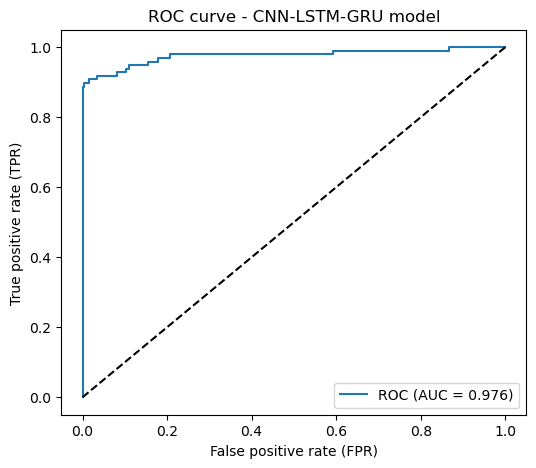

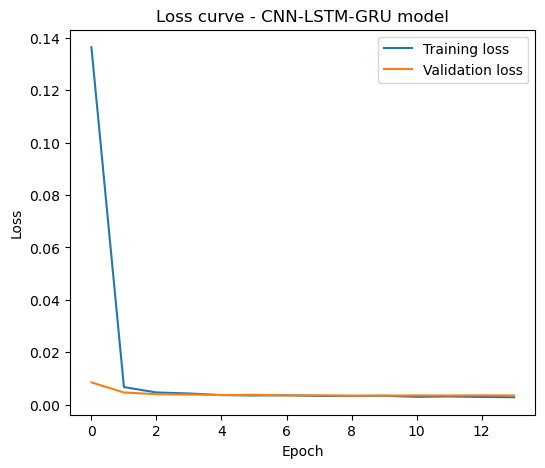

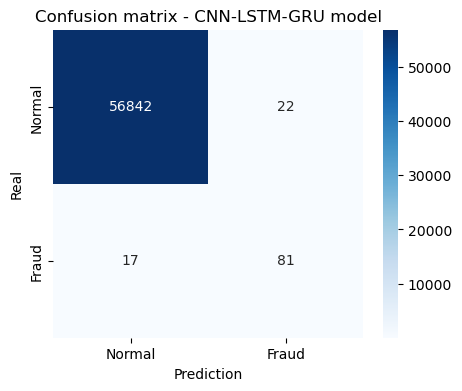

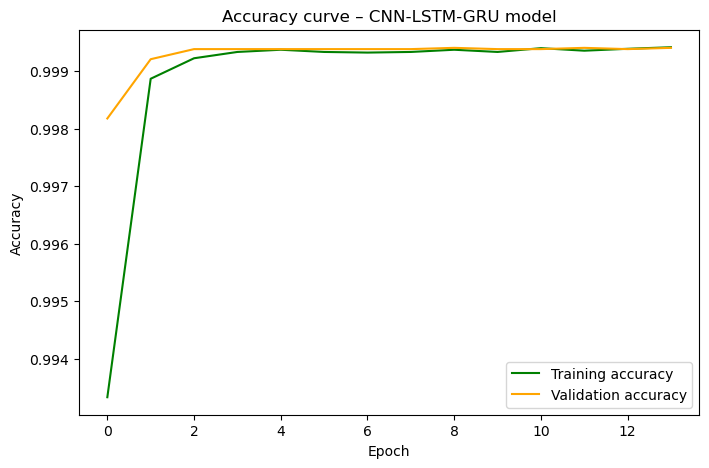

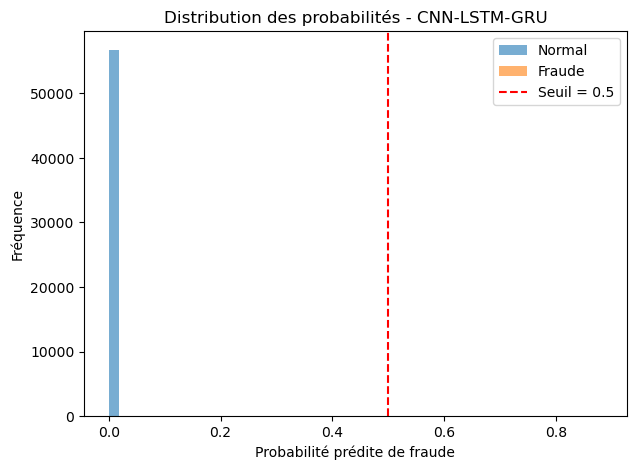

In [1]:
#🧩 CODE PYTHON COMPLET – Modèle Hybride CNN-LSTM-GRU

# ================================================================
# Détection de Fraudes Bancaires - Modèle Hybride CNN-LSTM-GRU
# Dataset : European Credit Card Fraud (Kaggle)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, matthews_corrcoef, classification_report
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, GRU, Dense, Dropout, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# ================================================================
# 1️⃣ Chargement et préparation du dataset
# ================================================================
df = pd.read_csv(r"C:..\creditcard.csv")
# placer le fichier dans le même dossier que le script

print("Taille du dataset :", df.shape)
print(df["Class"].value_counts())

# Séparation des features et du label
X = df.drop("Class", axis=1).values
y = df["Class"].values

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape pour CNN/LSTM/GRU (échantillons, pas de temps, caractéristiques)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# ================================================================
# 2️⃣ Construction du modèle CNN-LSTM-GRU
# ================================================================
model = Sequential([
    # Bloc CNN
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=1),
    Dropout(0.3),
    
    # Bloc LSTM
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    
    # Bloc GRU
    GRU(64, return_sequences=False),
    Dropout(0.3),
    
    # Couches fully connected
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ================================================================
# 3️⃣ Entraînement du modèle
# ================================================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=2048,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ================================================================
# 4️⃣ Évaluation du modèle
# ================================================================
y_pred_proba = model.predict(X_test).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

# Calcul des métriques
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Affichage des résultats
print("\n=== 📊 Évaluation du modèle CNN-LSTM-GRU ===")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Specificité    : {specificity:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"MCC            : {mcc:.4f}")
print(f"ROC AUC        : {roc_auc:.4f}")
print("\nMatrice de confusion :\n", cm)
print("\nRapport de classification :\n", classification_report(y_test, y_pred, digits=4))

# ================================================================
# 5️⃣ Visualisations
# ================================================================

# ✅ Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False positive rate (FPR)")
plt.ylabel("True positive rate (TPR)")
plt.title("ROC curve - CNN-LSTM-GRU model")
plt.legend()
plt.show()

# ✅ Courbes de perte
plt.figure(figsize=(6,5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title("Loss curve - CNN-LSTM-GRU model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ✅ Matrice de confusion visuelle
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
plt.title("Confusion matrix - CNN-LSTM-GRU model")
plt.ylabel("Real")
plt.xlabel("Prediction")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training accuracy", color='green')
plt.plot(history.history["val_accuracy"], label="Validation accuracy", color='orange')
plt.title("Accuracy curve – CNN-LSTM-GRU model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# ✅ Distribution des probabilités prédites
plt.figure(figsize=(7,5))
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.6, label='Normal')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.6, label='Fraude')
plt.axvline(0.5, color='r', linestyle='--', label='Seuil = 0.5')
plt.title("Distribution des probabilités - CNN-LSTM-GRU")
plt.xlabel("Probabilité prédite de fraude")
plt.ylabel("Fréquence")
plt.legend()
plt.show()



In [2]:
import joblib, json, numpy as np, os

# Création du dossier
os.makedirs("CNN-LSTM-GRU", exist_ok=True)

# Sauvegarde
model.save("CNN-LSTM-GRU/cnn_fraude.h5")
joblib.dump(scaler, "CNN-LSTM-GRU/scaler.pkl")
np.save("CNN-LSTM-GRU/fpr.npy", fpr)
np.save("CNN-LSTM-GRU/tpr.npy", tpr)
np.save("CNN-LSTM-GRU/history_loss.npy",     np.array(history.history['loss']))
np.save("CNN-LSTM-GRU/history_val_loss.npy", np.array(history.history['val_loss']))
np.save("CNN-LSTM-GRU/history_acc.npy",      np.array(history.history['accuracy']))
np.save("CNN-LSTM-GRU/history_val_acc.npy",  np.array(history.history['val_accuracy']))
np.save("CNN-LSTM-GRU/confusion_matrix.npy", cm)

metriques = {
    "accuracy":    round(float(accuracy),    4),
    "precision":   round(float(precision),   4),
    "recall":      round(float(recall),      4),
    "specificity": round(float(specificity), 4),
    "f1":          round(float(f1),          4),
    "mcc":         round(float(mcc),         4),
    "roc_auc":     round(float(roc_auc),     4)
}
with open("CNN-LSTM-GRU/metriques.json", "w") as f:
    json.dump(metriques, f, indent=4)

# Vérification
print("\n📂 Vérification CNN-LSTM-GRU :")
for fichier in ["CNN-LSTM-GRU/metriques.json","CNN-LSTM-GRU/confusion_matrix.npy",
                "CNN-LSTM-GRU/fpr.npy","CNN-LSTM-GRU/tpr.npy","CNN-LSTM-GRU/history_loss.npy"]:
    existe = "✅" if os.path.exists(fichier) else "❌"
    print(f"  {existe} {fichier}")


📂 Vérification CNN-LSTM-GRU :
  ✅ CNN-LSTM-GRU/metriques.json
  ✅ CNN-LSTM-GRU/confusion_matrix.npy
  ✅ CNN-LSTM-GRU/fpr.npy
  ✅ CNN-LSTM-GRU/tpr.npy
  ✅ CNN-LSTM-GRU/history_loss.npy
